# NLP: Embedding e TL-IDF Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar técnicas de NLP para processamento de linguagem para entedimento semântico e lexical das mensagens.

---

## Código

---

In [1]:
import pandas as pd

df_train = pd.read_parquet("../../dados/processed/train.parquet")
df_test = pd.read_parquet("../../dados/processed/test.parquet")

print("Primeiras linhas dados de treino")
print(df_train.head())
print("=" * 50)
print("Primeiras linhas dados de teste")
print(df_test.head())

Primeiras linhas dados de treino
                                            mensagem  log_duracao  \
0  irmão me fala o que a inglaterra vai arrumar c...     1.352393   
1  se preparem para dormir aqui pode po pera no s...     7.083835   
2  desgraça kkkkkkkkkkkkk perdigueiro dinâmico al...     6.692104   
3  é aqui no es eu ja sou explorado porra pelo me...     0.725937   
4  nada a ver <gif > @jão o radmin tá minerando b...     2.656757   

  dia_semana_inicio dia_semana_fim  hora_inicio  hora_fim  qtd_caracteres  \
0       Terça-feira    Terça-feira           17        18              93   
1            Sábado        Domingo           14        10              87   
2      Quinta-feira    Sexta-feira           22        11              77   
3      Quinta-feira   Quinta-feira           14        14              94   
4      Quarta-feira   Quarta-feira           20        21             146   

   qtd_palavras  caracter_por_palavra   membro  
0            19              4.894737  L

### Embedding

In [3]:
from sentence_transformers import SentenceTransformer
import os
import torch
os.environ["NUMBA_NUM_THREADS"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)

embeddings_train = model.encode(
    df_train["mensagem"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=128,
    device=device
)

Batches: 100%|██████████| 124/124 [00:09<00:00, 12.69it/s]


In [4]:
import numpy as np

rng = np.random.default_rng(42)

idx = rng.choice(
    len(embeddings_train),
    size=10_000,
    replace=False
)

emb_sample = embeddings_train[idx]

In [5]:
import umap

umap_vis = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    n_jobs=-1,
)

coords_2d = umap_vis.fit_transform(emb_sample)

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


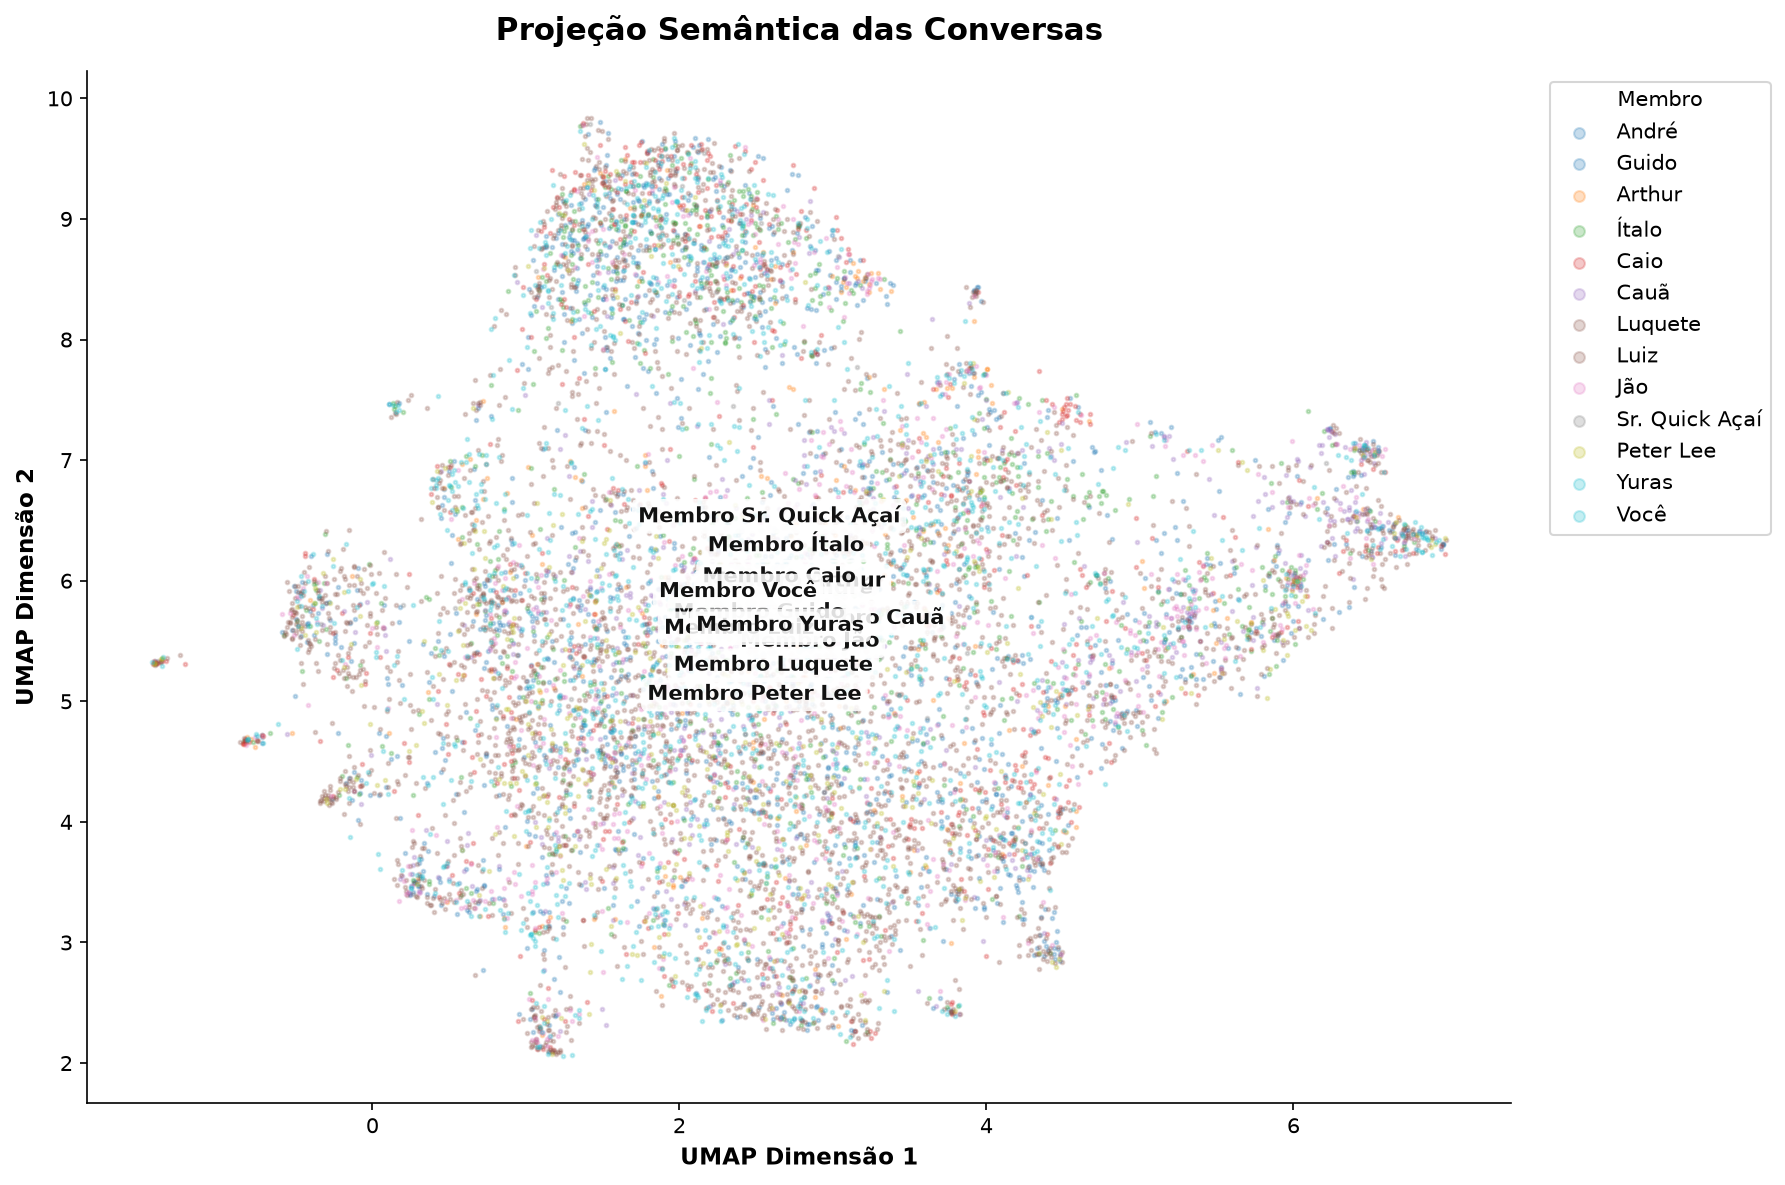

In [6]:
import matplotlib.pyplot as plt
import numpy as np

df_sample = df_train.iloc[idx]

df_sample["umap_x"] = coords_2d[:, 0]
df_sample["umap_y"] = coords_2d[:, 1]

plt.figure(figsize=(12, 8), dpi=150)

membros_unicos = df_sample["membro"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(membros_unicos)))

for i, membro in enumerate(membros_unicos):
    subset = df_sample[df_sample["membro"] == membro]
    plt.scatter(
        subset["umap_x"],
        subset["umap_y"],
        c=[colors[i]],
        label=str(membro),
        alpha=0.25,
        s=3,
        rasterized=True, 
    )

centroides_2d = df_sample.groupby("membro")[["umap_x", "umap_y"]].mean()

for c_id, row in centroides_2d.iterrows():
    plt.annotate(
        f"Membro {c_id}",
        (row["umap_x"], row["umap_y"]),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#111111",
        bbox=dict(boxstyle="round,pad=0.3", fc="#ffffffdd", ec="none"),
    )

plt.title(
    "Projeção Semântica das Conversas", fontsize=15, fontweight="bold", pad=15
)
plt.xlabel("UMAP Dimensão 1", fontsize=11, fontweight="bold")
plt.ylabel("UMAP Dimensão 2", fontsize=11, fontweight="bold")
plt.legend(
    title="Membro", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
embeddings_test = model.encode(
    df_test["mensagem"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=128,
    device=device
)

Batches: 100%|██████████| 31/31 [00:02<00:00, 12.30it/s]


In [9]:
np.save(
    "../../artifacts/embedding/embeddings_train.npy",
    embeddings_train
)

np.save(
    "../../artifacts/embedding/embeddings_test.npy",
    embeddings_test
)

### TL-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True
)

tfidf_train = vectorizer.fit_transform(df_train["mensagem"])

In [12]:
tfidf_sample = tfidf_train[idx]

In [13]:
coords_tfidf = umap_vis.fit_transform(tfidf_sample)

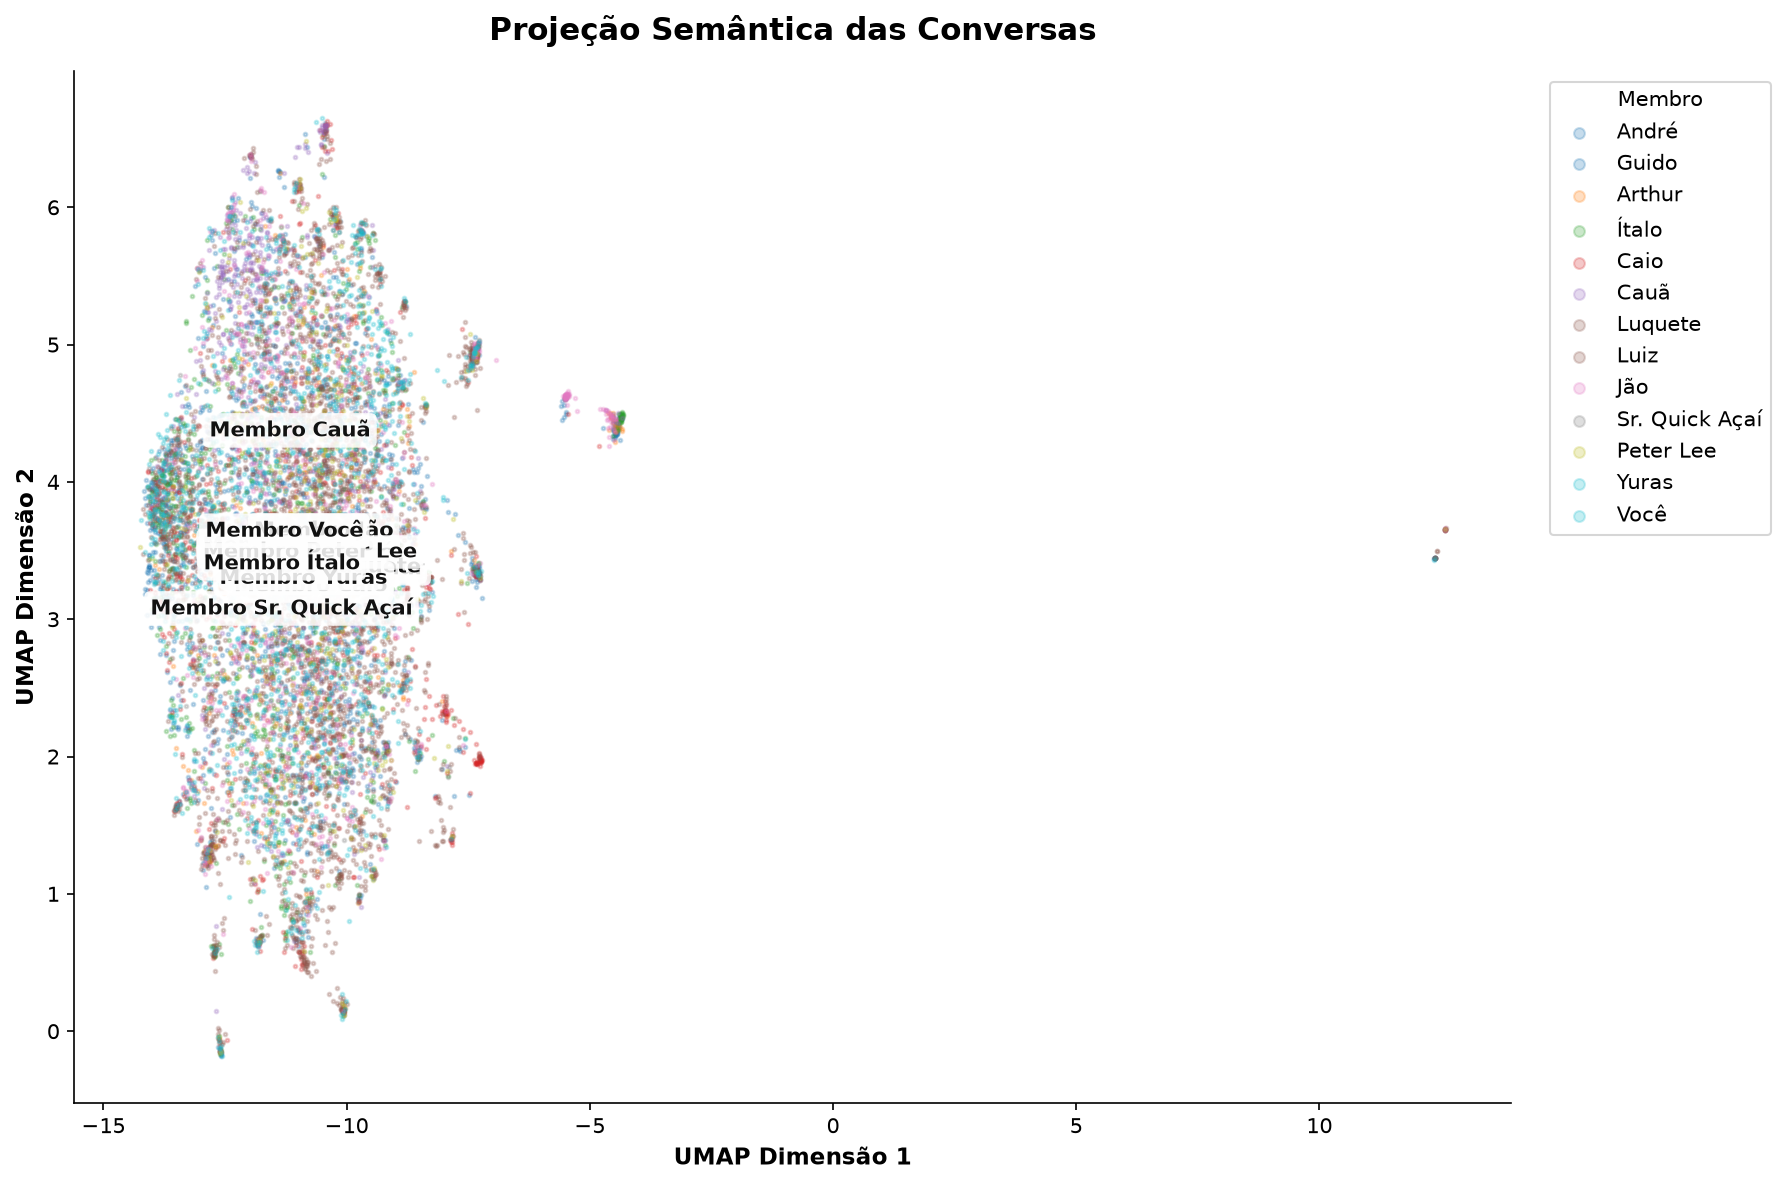

In [14]:
df_sample["umap_x"] = coords_tfidf[:, 0]
df_sample["umap_y"] = coords_tfidf[:, 1]

plt.figure(figsize=(12, 8), dpi=150)

membros_unicos = df_sample["membro"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(membros_unicos)))

for i, membro in enumerate(membros_unicos):
    subset = df_sample[df_sample["membro"] == membro]
    plt.scatter(
        subset["umap_x"],
        subset["umap_y"],
        c=[colors[i]],
        label=str(membro),
        alpha=0.25,
        s=3,
        rasterized=True, 
    )

centroides_2d = df_sample.groupby("membro")[["umap_x", "umap_y"]].mean()

for c_id, row in centroides_2d.iterrows():
    plt.annotate(
        f"Membro {c_id}",
        (row["umap_x"], row["umap_y"]),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#111111",
        bbox=dict(boxstyle="round,pad=0.3", fc="#ffffffdd", ec="none"),
    )

plt.title(
    "Projeção Semântica das Conversas", fontsize=15, fontweight="bold", pad=15
)
plt.xlabel("UMAP Dimensão 1", fontsize=11, fontweight="bold")
plt.ylabel("UMAP Dimensão 2", fontsize=11, fontweight="bold")
plt.legend(
    title="Membro", bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
tfidf_test = vectorizer.transform(df_test["mensagem"])

In [19]:
print("Treino:", tfidf_train.shape)
print("Teste:", tfidf_test.shape)
print("Features:", len(vectorizer.vocabulary_))
print("NNZ treino:", tfidf_train.nnz)
print("Sparsity:", tfidf_train.nnz / (tfidf_train.shape[0] * tfidf_train.shape[1]))

Treino: (15796, 100000)
Teste: (3949, 100000)
Features: 100000
NNZ treino: 5981301
Sparsity: 0.0037865921752342365


In [20]:
import joblib
from scipy import sparse

# Matrizes
sparse.save_npz(
    "../../artifacts/tfidf/tfidf_train.npz",
    tfidf_train
)

sparse.save_npz(
    "../../artifacts/tfidf/tfidf_test.npz",
    tfidf_test
)

# Vectorizer
joblib.dump(
    vectorizer,
    "../../artifacts/tfidf/tfidf_vectorizer.joblib"
)

['../../artifacts/tfidf/tfidf_vectorizer.joblib']